In [ ]:
import pandas as pd                          # Loading and manipulating data
import numpy as np                           # Numerical operations

from sklearn.model_selection import train_test_split   # Splitting data into training and testing sets

from sklearn.preprocessing import OneHotEncoder        # Converting categorical features into numerical format
from sklearn.preprocessing import StandardScaler       # Scaling numerical features to a common range

from sklearn.compose import ColumnTransformer          # Applying different preprocessing steps to different columns
from sklearn.pipeline import Pipeline                  # Chaining all preprocessing and modeling steps together

from xgboost import XGBClassifier                      # Main machine learning model for churn prediction

from sklearn.metrics import classification_report      # Displays Precision, Recall, and F1-score
from sklearn.metrics import confusion_matrix           # Shows correct and incorrect predictions in matrix form
from sklearn.metrics import roc_auc_score              # Measures the model's overall classification performance

import matplotlib.pyplot as plt                        # Creating visualizations and plots
import seaborn as sns                                  # Creating enhanced statistical visualizations


In [3]:
df = pd.read_csv('D:\COEP\FintelliQ\data\churn_features.csv')

print(df.shape)
print(df.columns.tolist())

(10000, 16)
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Exited', 'IsZeroBalance', 'AgeGroup', 'IsHighRiskProduct', 'IsGermany', 'BalanceToSalaryRatio', 'IsInactiveSenior', 'IsFemaleGermany']


In [ ]:
# differentiating X and Y
X = df.drop(columns=['Exited'])
y = df['Exited']

print("Features:", X.shape)
print("Target distribution:")
print(y.value_counts())

Features: (10000, 15)
Target distribution:
Exited
0    7962
1    2038
Name: count, dtype: int64


In [5]:
# Categorical columns : need OneHotEncoder
categorical_cols = ['Geography', 'AgeGroup']

# Numerical columns : need StandardScaler
numerical_cols = ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance',
                  'NumOfProducts', 'IsActiveMember', 'IsZeroBalance',
                  'IsHighRiskProduct', 'IsGermany', 'BalanceToSalaryRatio',
                  'IsInactiveSenior', 'IsFemaleGermany']

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['Geography', 'AgeGroup']
Numerical: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'IsActiveMember', 'IsZeroBalance', 'IsHighRiskProduct', 'IsGermany', 'BalanceToSalaryRatio', 'IsInactiveSenior', 'IsFemaleGermany']


### Why `stratify=y` is used

When performing a train-test split, it is important to maintain the same target class distribution in both datasets.

**Without `stratify`:**
- The split is completely random.
- The churn rate in the training and testing sets may differ.
- This can lead to misleading model evaluation results.

**With `stratify=y`:**
- The data is grouped according to the target variable (`Exited`).
- Each group is split proportionally into training and testing sets.
- Both datasets preserve the original churn/non-churn ratio.

**Example:**
If 20% of customers have churned in the original dataset:
- Training set → ~20% churned customers
- Testing set → ~20% churned customers

This ensures that the model is trained and evaluated on data with a consistent class distribution, resulting in a fair and reliable performance assessment.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducible results
    stratify=y            # maintains 80-20 churn ratio in both splits
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

Train size: (8000, 15)
Test size: (2000, 15)

Train churn rate: 0.204
Test churn rate: 0.204


In [7]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=4,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [8]:
pipeline.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [10]:
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba), 3))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      1592
           1       0.54      0.71      0.62       408

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.82      0.83      2000

ROC-AUC Score: 0.864


## Model Performance Analysis

### ROC-AUC Score: 0.864

A ROC-AUC score of **0.864** indicates strong model performance. It means the model can distinguish between customers who are likely to churn and those who are likely to stay with **86.4% effectiveness**. In customer churn prediction problems, an AUC above **0.85** is generally considered very good.

---

## Understanding the Key Metrics

### Precision
**Precision measures how many customers predicted as churners actually churned.**

Formula:

Precision = True Positives / (True Positives + False Positives)

Higher Precision means fewer false alarms.

**Business Interpretation:**  
If the model predicts 100 customers will churn and 54 actually churn, the Precision is 54%.

---

### Recall
**Recall measures how many actual churners the model successfully identified.**

Formula:

Recall = True Positives / (True Positives + False Negatives)

Higher Recall means fewer churners are missed.

**Business Interpretation:**  
If 100 customers actually churn and the model identifies 71 of them, the Recall is 71%.

---

### F1-Score
**F1-Score is the harmonic mean of Precision and Recall.**

Formula:

F1 = 2 × (Precision × Recall) / (Precision + Recall)

It provides a single metric that balances both Precision and Recall.

**Business Interpretation:**  
A high F1-Score indicates that the model is both finding churners effectively (high Recall) and making accurate churn predictions (high Precision).

---

## Class 1: Churned Customers

| Metric | Value | Interpretation |
|----------|----------|----------|
| Precision | 0.54 | Out of all customers predicted to churn, 54% actually churned |
| Recall | 0.71 | The model successfully identifies 71% of actual churned customers |
| F1-Score | 0.62 | Indicates a reasonable balance between Precision and Recall |

### Key Insight

The model captures most churners, successfully identifying **71% of customers who actually churned**. However, the Precision of **54%** indicates that some customers are incorrectly flagged as churn risks.

---

## Class 0: Retained Customers

| Metric | Value |
|----------|----------|
| Precision | 0.92 |
| Recall | 0.84 |
| F1-Score | 0.88 |

### Key Insight

The model performs very well at identifying customers who will remain with the bank, achieving high Precision and strong Recall.

---

## Overall Assessment

### Strengths

- ROC-AUC of **0.864** indicates strong discriminative ability.
- The model successfully identifies **71% of churning customers**.
- Retained customers are predicted with high accuracy.
- Performance is strong for an initial churn prediction model.

### Areas for Improvement

- Precision for churn prediction is **0.54**, meaning nearly half of the customers predicted as churners do not actually churn.
- F1-Score of **0.62** is acceptable but can be improved.
- Future improvements may include threshold tuning, hyperparameter optimization, class balancing techniques, and additional feature engineering.

---

## Conclusion

The model demonstrates strong overall performance and is effective at identifying customers at risk of churn. While customer retention predictions are highly reliable, improving churn prediction Precision should be the primary focus of future iterations to reduce false positives and increase business efficiency.

In [14]:
#improving prediction model
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pipeline_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric='logloss'
    ))
])

pipeline_smote.fit(X_train, y_train)
print("SMOTE Model trained successfully")

SMOTE Model trained successfully


In [15]:
y_pred_smote = pipeline_smote.predict(X_test)
y_pred_proba_smote = pipeline_smote.predict_proba(X_test)[:, 1]

print("Classification Report (with SMOTE):")
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba_smote), 3))

Classification Report (with SMOTE):
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1592
           1       0.68      0.58      0.63       408

    accuracy                           0.86      2000
   macro avg       0.79      0.76      0.77      2000
weighted avg       0.85      0.86      0.85      2000

ROC-AUC Score: 0.863


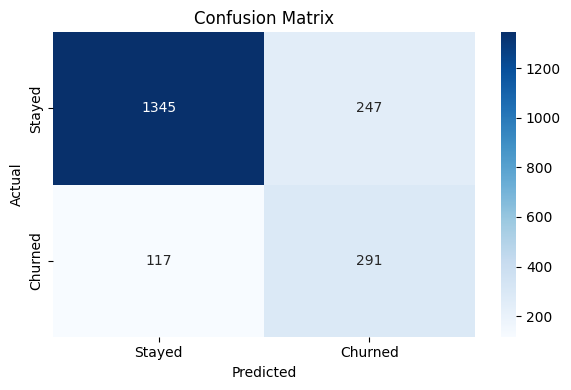

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    pipeline, X, y,
    cv=cv,
    scoring=['f1', 'recall', 'precision', 'roc_auc'],
    return_train_score=True
)

print("Cross Validation Results (5 Fold):")
print(f"F1:        {scores['test_f1'].mean():.3f} (+/- {scores['test_f1'].std():.3f})")
print(f"Recall:    {scores['test_recall'].mean():.3f} (+/- {scores['test_recall'].std():.3f})")
print(f"Precision: {scores['test_precision'].mean():.3f} (+/- {scores['test_precision'].std():.3f})")
print(f"ROC-AUC:   {scores['test_roc_auc'].mean():.3f} (+/- {scores['test_roc_auc'].std():.3f})")

Cross Validation Results (5 Fold):
F1:        0.601 (+/- 0.013)
Recall:    0.695 (+/- 0.016)
Precision: 0.530 (+/- 0.013)
ROC-AUC:   0.852 (+/- 0.007)


In [18]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [4, 5, 6, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__scale_pos_weight': [3, 4, 5]
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
print("Best F1 Score:", round(search.best_score_, 3))
print("Best Parameters:", search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best F1 Score: 0.619
Best Parameters: {'model__subsample': 0.7, 'model__scale_pos_weight': 3, 'model__n_estimators': 300, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}


In [19]:
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.7,
        colsample_bytree=1.0,
        scale_pos_weight=3,
        random_state=42,
        eval_metric='logloss'
    ))
])

best_pipeline.fit(X_train, y_train)
print("Final model trained successfully")

Final model trained successfully


In [20]:
y_pred_final = best_pipeline.predict(X_test)
y_pred_proba_final = best_pipeline.predict_proba(X_test)[:, 1]

print("Final Model Results:")
print(classification_report(y_test, y_pred_final))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba_final), 3))

Final Model Results:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1592
           1       0.57      0.71      0.63       408

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.76      2000
weighted avg       0.85      0.83      0.84      2000

ROC-AUC: 0.874
